In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Load datasets
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
perf = pd.read_csv("../data/processed/scheme_performance_clean.csv")
bench = pd.read_csv("../data/raw/Copy of 10_benchmark_indices.csv")

# Date conversion
nav["date"] = pd.to_datetime(nav["date"])
bench["date"] = pd.to_datetime(bench["date"])

print("NAV Shape:", nav.shape)
print("Performance Shape:", perf.shape)
print("Benchmark Shape:", bench.shape)

NAV Shape: (46000, 3)
Performance Shape: (40, 20)
Benchmark Shape: (8050, 3)


In [3]:
# Daily Returns

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav[["amfi_code", "date", "nav", "daily_return"]].head(10))
print("\nMissing daily returns:", nav["daily_return"].isna().sum())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073

Missing daily returns: 40


In [4]:
# Check date coverage

coverage = (
    nav.groupby("amfi_code")
       .agg(
           start_date=("date", "min"),
           end_date=("date", "max"),
           observations=("date", "count")
       )
)

print(coverage.head())
print("\nUnique observation counts:")
print(coverage["observations"].value_counts().head())

          start_date   end_date  observations
amfi_code                                    
100016    2022-01-03 2026-05-29          1150
100025    2022-01-03 2026-05-29          1150
100033    2022-01-03 2026-05-29          1150
101206    2022-01-03 2026-05-29          1150
101207    2022-01-03 2026-05-29          1150

Unique observation counts:
observations
1150    40
Name: count, dtype: int64


In [5]:
# CAGR Calculation

cagr_df = (
    nav.groupby("amfi_code")
       .agg(
           start_nav=("nav", "first"),
           end_nav=("nav", "last")
       )
       .reset_index()
)

years = 3

cagr_df["cagr"] = (
    (cagr_df["end_nav"] / cagr_df["start_nav"]) ** (1 / years) - 1
)

cagr_df = cagr_df.sort_values("cagr", ascending=False)

print(cagr_df.head())

    amfi_code  start_nav   end_nav      cagr
25     120505   135.8720  473.7640  0.516389
21     119598    89.8738  309.2050  0.509632
39     149324    81.6814  279.7511  0.507357
36     148569    28.8620   97.7435  0.501714
34     148567    70.2514  230.2708  0.485461


In [6]:
print("Min Date:", nav["date"].min())
print("Max Date:", nav["date"].max())

Min Date: 2022-01-03 00:00:00
Max Date: 2026-05-29 00:00:00


In [7]:
# Restrict to last 3 years

end_date = nav["date"].max()
start_3yr = end_date - pd.DateOffset(years=3)

nav_3yr = nav[nav["date"] >= start_3yr].copy()

print("3-Year Start:", start_3yr.date())
print("3-Year End:", end_date.date())
print("Rows:", len(nav_3yr))
print("Funds:", nav_3yr["amfi_code"].nunique())

3-Year Start: 2023-05-29
3-Year End: 2026-05-29
Rows: 31400
Funds: 40


In [8]:
# Correct 3-Year CAGR

cagr_3yr = (
    nav_3yr.groupby("amfi_code")
           .agg(
               start_nav=("nav", "first"),
               end_nav=("nav", "last")
           )
           .reset_index()
)

cagr_3yr["cagr_3yr"] = (
    (cagr_3yr["end_nav"] / cagr_3yr["start_nav"]) ** (1 / 3) - 1
)

cagr_3yr = cagr_3yr.sort_values(
    "cagr_3yr",
    ascending=False
)

print(cagr_3yr.head())
print("\nCAGR Range:")
print(cagr_3yr["cagr_3yr"].describe())

    amfi_code  start_nav   end_nav  cagr_3yr
16     119094    82.6510  203.8581  0.351118
34     148567    95.7008  230.2708  0.340009
24     120504    64.9875  151.1311  0.324874
2      100033   147.2155  342.0072  0.324425
25     120505   207.0322  473.7640  0.317775

CAGR Range:
count    40.000000
mean      0.164147
std       0.122068
min      -0.117058
25%       0.066009
50%       0.182331
75%       0.269026
max       0.351118
Name: cagr_3yr, dtype: float64


In [9]:
# Sharpe Ratio

RF = 0.065  # 6.5% annual risk-free rate

sharpe_df = (
    nav_3yr.groupby("amfi_code")
           .agg(
               mean_daily_return=("daily_return", "mean"),
               std_daily_return=("daily_return", "std")
           )
           .reset_index()
)

sharpe_df["annual_return"] = sharpe_df["mean_daily_return"] * 252

sharpe_df["sharpe_ratio"] = (
    (sharpe_df["annual_return"] - RF)
    /
    (sharpe_df["std_daily_return"] * np.sqrt(252))
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

print(sharpe_df.head())
print("\nSharpe Summary:")
print(sharpe_df["sharpe_ratio"].describe())

    amfi_code  mean_daily_return  std_daily_return  annual_return  sharpe_ratio
34     148567           0.001155          0.008819       0.291007      1.614434
24     120504           0.001103          0.009061       0.277840      1.479645
19     119551           0.001051          0.008783       0.264903      1.433735
3      101206           0.001005          0.009137       0.253290      1.298103
30     120843           0.001044          0.009970       0.263168      1.252066

Sharpe Summary:
count    40.000000
mean      0.516184
std       0.717108
min      -1.201122
25%      -0.233920
50%       0.744162
75%       1.017961
max       1.614434
Name: sharpe_ratio, dtype: float64


In [10]:
# Sortino Ratio

sortino_list = []

for fund, grp in nav_3yr.groupby("amfi_code"):

    mean_daily_return = grp["daily_return"].mean()

    downside_returns = grp.loc[
        grp["daily_return"] < 0,
        "daily_return"
    ]

    downside_std = downside_returns.std()

    annual_return = mean_daily_return * 252

    sortino_ratio = (
        (annual_return - RF)
        /
        (downside_std * np.sqrt(252))
    )

    sortino_list.append([
        fund,
        annual_return,
        downside_std,
        sortino_ratio
    ])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "annual_return",
        "downside_std",
        "sortino_ratio"
    ]
)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

print(sortino_df.head())
print("\nSortino Summary:")
print(sortino_df["sortino_ratio"].describe())

    amfi_code  annual_return  downside_std  sortino_ratio
34     148567       0.291007      0.005398       2.637558
24     120504       0.277840      0.005143       2.607085
19     119551       0.264903      0.004966       2.535686
3      101206       0.253290      0.004970       2.386585
30     120843       0.263168      0.005466       2.283838

Sortino Summary:
count    40.000000
mean      0.895485
std       1.281985
min      -2.556053
25%      -0.386704
50%       1.271167
75%       1.757935
max       2.637558
Name: sortino_ratio, dtype: float64


In [11]:
# NIFTY100 benchmark

nifty100 = bench[bench["index_name"] == "NIFTY100"].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

print(nifty100.head())
print("\nRows:", len(nifty100))
print("Missing benchmark returns:", nifty100["benchmark_return"].isna().sum())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150

Rows: 1150
Missing benchmark returns: 1


In [12]:
# Merge benchmark returns with fund returns

benchmark_returns = nifty100[
    ["date", "benchmark_return"]
].copy()

fund_benchmark = nav_3yr.merge(
    benchmark_returns,
    on="date",
    how="inner"
)

print("Merged Shape:", fund_benchmark.shape)

print("\nMissing Fund Returns:")
print(fund_benchmark["daily_return"].isna().sum())

print("\nMissing Benchmark Returns:")
print(fund_benchmark["benchmark_return"].isna().sum())

fund_benchmark.head()

Merged Shape: (31400, 5)

Missing Fund Returns:
0

Missing Benchmark Returns:
0


,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2023-05-29,561.5519,-0.008540,0.000667
1,100016,2023-05-30,565.9312,0.007799,-0.001613
2,100016,2023-05-31,562.0590,-0.006842,-0.003352
3,100016,2023-06-01,565.0931,0.005398,-0.007142
4,100016,2023-06-02,563.6716,-0.002516,0.003643


In [13]:
# Alpha & Beta using NIFTY100

alpha_beta_list = []

for fund, grp in fund_benchmark.groupby("amfi_code"):

    result = linregress(
        grp["benchmark_return"],
        grp["daily_return"]
    )

    beta = result.slope

    # Task specification:
    # Alpha = intercept × 252
    alpha = result.intercept * 252

    alpha_beta_list.append([
        fund,
        alpha,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_list,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
)

print(alpha_beta_df.head())
print("\nAlpha Summary:")
print(alpha_beta_df["alpha"].describe())

print("\nBeta Summary:")
print(alpha_beta_df["beta"].describe())

    amfi_code     alpha      beta
16     119094  0.315900 -0.100635
2      100033  0.291127 -0.026855
34     148567  0.289333  0.018818
25     120505  0.289169 -0.047272
24     120504  0.272616  0.058741

Alpha Summary:
count    40.000000
mean      0.153789
std       0.103252
min      -0.081171
25%       0.061638
50%       0.167727
75%       0.250533
max       0.315900
Name: alpha, dtype: float64

Beta Summary:
count    40.000000
mean     -0.002254
std       0.050391
min      -0.134265
25%      -0.033259
50%      -0.003413
75%       0.028952
max       0.165552
Name: beta, dtype: float64


In [14]:
print(fund_benchmark[["daily_return", "benchmark_return"]].corr())

                  daily_return  benchmark_return
daily_return          1.000000         -0.001769
benchmark_return     -0.001769          1.000000


In [15]:
sample_fund = fund_benchmark["amfi_code"].iloc[0]

test = fund_benchmark[
    fund_benchmark["amfi_code"] == sample_fund
]

print("Fund:", sample_fund)

print(
    test[["daily_return", "benchmark_return"]]
    .corr()
)

Fund: 100016
                  daily_return  benchmark_return
daily_return            1.0000           -0.0348
benchmark_return       -0.0348            1.0000


In [16]:
sample_fund = 100016

test = fund_benchmark[
    fund_benchmark["amfi_code"] == sample_fund
]

slope, intercept, r_value, p_value, std_err = linregress(
    test["benchmark_return"],
    test["daily_return"]
)

print("Alpha:", intercept)
print("Beta :", slope)
print("R²    :", r_value**2)

Alpha: 9.269415704544676e-05
Beta : -0.03908553105865191
R²    : 0.001211057210791938


In [17]:
# Maximum Drawdown

drawdown_df = nav_3yr.copy()

drawdown_df["cum_max"] = (
    drawdown_df.groupby("amfi_code")["nav"]
    .cummax()
)

drawdown_df["drawdown"] = (
    drawdown_df["nav"] - drawdown_df["cum_max"]
) / drawdown_df["cum_max"]

max_dd = (
    drawdown_df.groupby("amfi_code")["drawdown"]
    .min()
    .reset_index()
    .rename(columns={"drawdown": "max_drawdown"})
)

max_dd = max_dd.sort_values(
    "max_drawdown"
)

print(max_dd.head())

print("\nDrawdown Summary:")
print(max_dd["max_drawdown"].describe())

    amfi_code  max_drawdown
17     119095     -0.516778
22     119599     -0.425428
4      101207     -0.354469
39     149324     -0.311719
21     119598     -0.287060

Drawdown Summary:
count    40.000000
mean     -0.167204
std       0.105892
min      -0.516778
25%      -0.189417
50%      -0.153807
75%      -0.111391
max      -0.000977
Name: max_drawdown, dtype: float64


In [18]:
# Annualized Volatility

volatility_df = (
    nav_3yr.groupby("amfi_code")["daily_return"]
    .std()
    .reset_index()
)

volatility_df["annual_volatility"] = (
    volatility_df["daily_return"] * np.sqrt(252)
)

volatility_df = volatility_df.sort_values(
    "annual_volatility",
    ascending=False
)

print(volatility_df.head())

print("\nVolatility Summary:")
print(volatility_df["annual_volatility"].describe())

    amfi_code  daily_return  annual_volatility
4      101207      0.016080           0.255260
21     119598      0.016063           0.254998
11     118634      0.016034           0.254539
17     119095      0.015789           0.250642
39     149324      0.015662           0.248632

Volatility Summary:
count    40.000000
mean      0.148697
std       0.066520
min       0.004876
25%       0.137233
50%       0.144448
75%       0.178778
max       0.255260
Name: annual_volatility, dtype: float64


In [19]:
# Master Performance Table

performance_table = (
    cagr_3yr[["amfi_code", "cagr_3yr"]]
    .merge(
        sharpe_df[["amfi_code", "sharpe_ratio"]],
        on="amfi_code"
    )
    .merge(
        sortino_df[["amfi_code", "sortino_ratio"]],
        on="amfi_code"
    )
    .merge(
        alpha_beta_df[["amfi_code", "alpha", "beta"]],
        on="amfi_code"
    )
    .merge(
        max_dd,
        on="amfi_code"
    )
    .merge(
        volatility_df[["amfi_code", "annual_volatility"]],
        on="amfi_code"
    )
)

print(performance_table.shape)
performance_table.head()

(40, 8)


,amfi_code,cagr_3yr,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,annual_volatility
0,119094,0.351118,1.243753,2.227587,0.315900,-0.100635,-0.147154,0.194532
1,148567,0.340009,1.614434,2.637558,0.289333,0.018818,-0.112657,0.139991
2,120504,0.324874,1.479645,2.607085,0.272616,0.058741,-0.123581,0.143845
3,100033,0.324425,1.224870,2.099624,0.291127,-0.026855,-0.155842,0.182663
4,120505,0.317775,1.155939,1.953703,0.289169,-0.047272,-0.181885,0.190291


In [20]:
# Add Scheme Names

scheme_lookup = (
    perf[["amfi_code", "scheme_name", "fund_house", "category"]]
    .drop_duplicates()
)

performance_table = performance_table.merge(
    scheme_lookup,
    on="amfi_code",
    how="left"
)

print(performance_table.shape)

performance_table.head()

(40, 11)


,amfi_code,cagr_3yr,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,annual_volatility,scheme_name,fund_house,category
0,119094,0.351118,1.243753,2.227587,0.315900,-0.100635,-0.147154,0.194532,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap
1,148567,0.340009,1.614434,2.637558,0.289333,0.018818,-0.112657,0.139991,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap
2,120504,0.324874,1.479645,2.607085,0.272616,0.058741,-0.123581,0.143845,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap
3,100033,0.324425,1.224870,2.099624,0.291127,-0.026855,-0.155842,0.182663,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap
4,120505,0.317775,1.155939,1.953703,0.289169,-0.047272,-0.181885,0.190291,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap


In [21]:
# Rank Funds by CAGR

top_cagr = (
    performance_table
    .sort_values("cagr_3yr", ascending=False)
)

print(
    top_cagr[
        ["scheme_name",
         "category",
         "cagr_3yr",
         "sharpe_ratio",
         "max_drawdown"]
    ].head(10)
)

                                         scheme_name   category  cagr_3yr  sharpe_ratio  max_drawdown
0                Axis Midcap Fund - Regular - Growth    Mid Cap  0.351118      1.243753     -0.147154
1      Mirae Asset Large Cap Fund - Regular - Growth  Large Cap  0.340009      1.614434     -0.112657
2          ICICI Pru Bluechip Fund - Direct - Growth  Large Cap  0.324874      1.479645     -0.123581
3  HDFC Mid-Cap Opportunities Fund - Regular - Gr...    Mid Cap  0.324425      1.224870     -0.155842
4           ICICI Pru Midcap Fund - Regular - Growth    Mid Cap  0.317775      1.155939     -0.181885
5          SBI Bluechip Fund - Regular Plan - Growth  Large Cap  0.304565      1.433735     -0.150124
6             Kotak Flexicap Fund - Regular - Growth  Flexi Cap  0.295828      1.252066     -0.107594
7      Mirae Asset Tax Saver Fund - Regular - Growth       ELSS  0.291789      1.135917     -0.163967
8      ABSL Frontline Equity Fund - Regular - Growth  Large Cap  0.289677      1.2

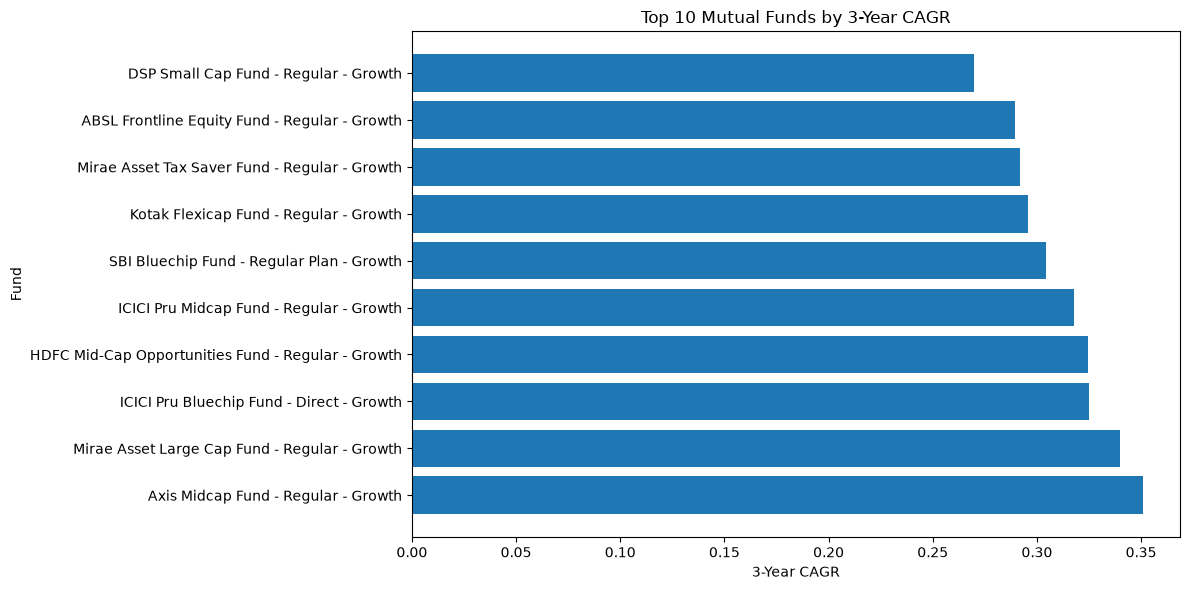

In [22]:
# Top 10 Funds by CAGR

top10 = (
    performance_table
    .sort_values("cagr_3yr", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["cagr_3yr"]
)

plt.xlabel("3-Year CAGR")
plt.ylabel("Fund")
plt.title("Top 10 Mutual Funds by 3-Year CAGR")

plt.tight_layout()

plt.savefig(
    "../reports/Top10_Funds_by_CAGR.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

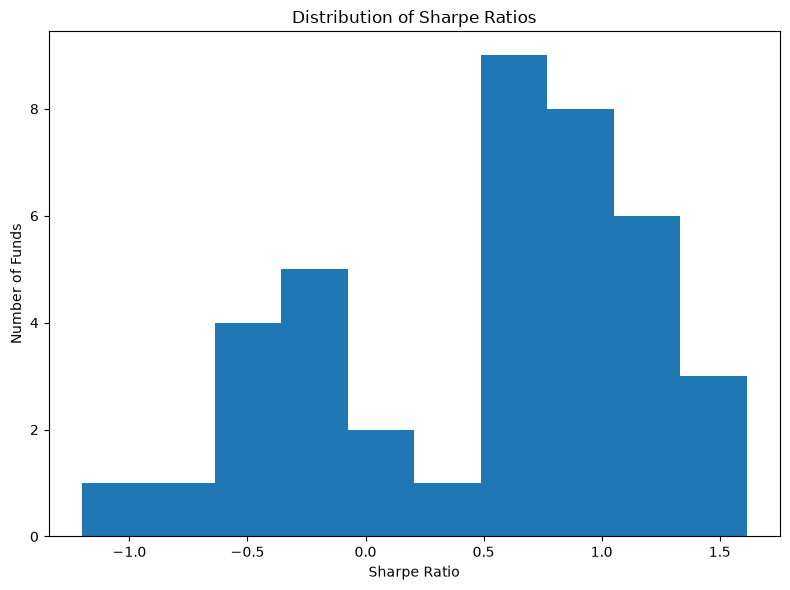

In [23]:
# Sharpe Ratio Distribution

plt.figure(figsize=(8,6))

plt.hist(
    performance_table["sharpe_ratio"],
    bins=10
)

plt.xlabel("Sharpe Ratio")
plt.ylabel("Number of Funds")
plt.title("Distribution of Sharpe Ratios")

plt.tight_layout()

plt.savefig(
    "../reports/Sharpe_Ratio_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

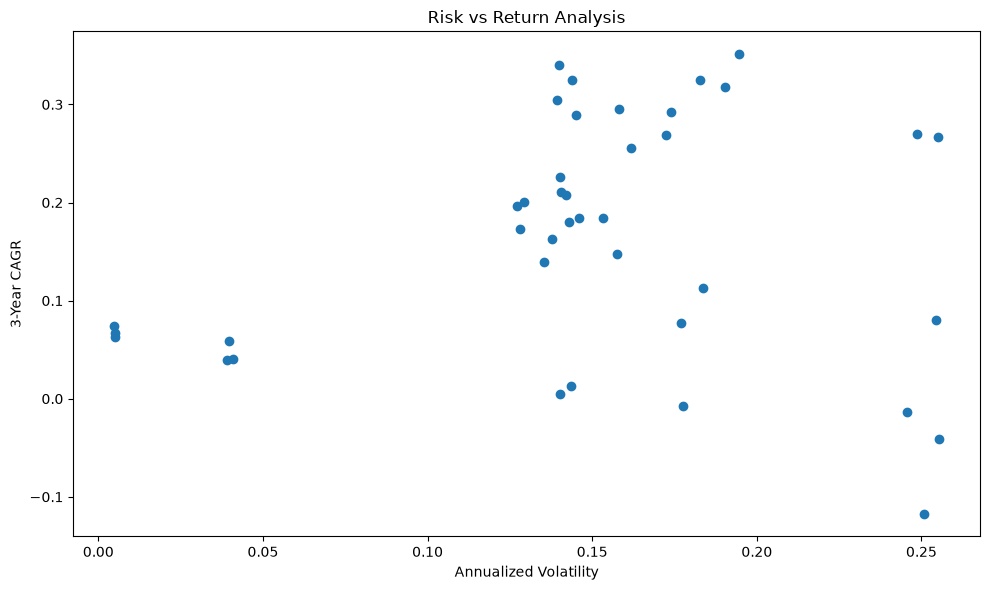

In [24]:
# Risk vs Return

plt.figure(figsize=(10,6))

plt.scatter(
    performance_table["annual_volatility"],
    performance_table["cagr_3yr"]
)

plt.xlabel("Annualized Volatility")
plt.ylabel("3-Year CAGR")
plt.title("Risk vs Return Analysis")

plt.tight_layout()

plt.savefig(
    "../reports/Risk_vs_Return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

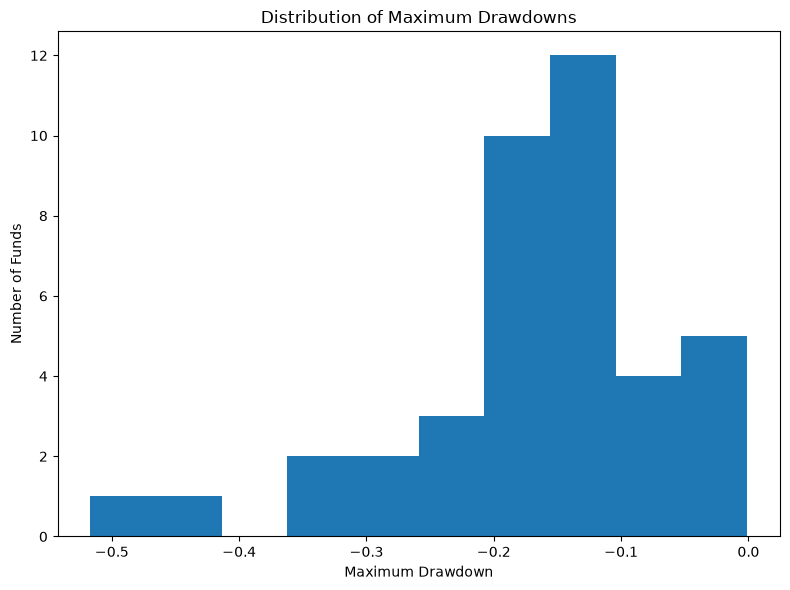

In [25]:
# Maximum Drawdown Distribution

plt.figure(figsize=(8,6))

plt.hist(
    performance_table["max_drawdown"],
    bins=10
)

plt.xlabel("Maximum Drawdown")
plt.ylabel("Number of Funds")
plt.title("Distribution of Maximum Drawdowns")

plt.tight_layout()

plt.savefig(
    "../reports/Maximum_Drawdown_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()